# Launcher bootstrap offline v5

Ce notebook sert a lancer et inspecter le pipeline bootstrap v5 depuis Jupyter. Les sorties restent offline: rien n'est branche au bot live, et les labels ne sont pas des labels GTO.


## Garde-fous

- Pipeline cible: v5 dist-aligned uniquement.
- Les warnings `not_gto`, `not_for_production`, `contains_weak_rule_labels` et `call_class_absent` restent des signaux a surveiller.
- Des metriques parfaites sont interpretees comme signal d'overfit probable, pas comme preuve de qualite strategique.
- Le run `v5_4000` ecrit dans des dossiers separes et ne remplace pas le baseline `v5`.


In [69]:
from pathlib import Path
import csv
import json
import subprocess
import sys
from collections import Counter, defaultdict

ROOT = Path.cwd()
PYTHON = sys.executable

V5_CANDIDATES = ROOT / "outputs/readiness/bootstrap_candidate_dataset_v5/candidates.csv"
V5_MODEL_DIR = ROOT / "outputs/readiness/bootstrap_model_v5"
V5_TRAINING_REPORT = V5_MODEL_DIR / "training_report_v5.json"
V5_4000_DIR = ROOT / "outputs/readiness/bootstrap_candidate_dataset_v5_4000"
V5_4000_CANDIDATES = V5_4000_DIR / "candidates.csv"
V5_4000_MODEL_DIR = ROOT / "outputs/readiness/bootstrap_model_v5_4000"
V5_4000_TRAINING_REPORT = V5_4000_MODEL_DIR / "training_report.json"
V5_4000_COMPARISON = V5_4000_MODEL_DIR / "comparison_v5_vs_v5_4000.json"

def run_cmd(args, *, timeout=None):
    print("$", " ".join(str(part) for part in args))
    completed = subprocess.run(
        [str(part) for part in args],
        cwd=ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    print(completed.stdout)
    if completed.returncode != 0:
        raise RuntimeError(f"Commande echouee: {completed.returncode}")
    return completed.stdout

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def load_csv(path):
    with Path(path).open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))

def is_true(value):
    return str(value).strip().lower() in {"true", "1", "yes"}

print("Projet:", ROOT)
print("Python:", PYTHON)


Projet: c:\Users\Éleve\Pictures\Traine_aide_decission
Python: c:\Users\Éleve\AppData\Local\Programs\Python\Python313\python.exe


## Lancements

Execute seulement les cellules dont tu as besoin. Le run `v5_4000` peut etre long; le training v5 simple est plus court.


## Training v5 dist-aligned

Cette cellule entraine le modele offline sur `outputs/readiness/bootstrap_candidate_dataset_v5/candidates.csv`. Elle ne branche rien au bot live et n'ajoute pas `CALL`.


In [70]:
train = True  # Mettre True pour lancer toute la suite pytest depuis le notebook.
RUN_V5_TRAINING = train

if RUN_V5_TRAINING:
    run_cmd([
        PYTHON,
        "experiments/train_bootstrap_v5.py",
        "--input", V5_CANDIDATES,
        "--output-dir", V5_MODEL_DIR,
        "--min-rows", 100,
        "--random-seed", 17,
    ], timeout=120)
else:
    print("Training v5 ignore. Passe RUN_V5_TRAINING=True pour le lancer.")


$ c:\Users\Éleve\AppData\Local\Programs\Python\Python313\python.exe experiments/train_bootstrap_v5.py --input c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_candidate_dataset_v5\candidates.csv --output-dir c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5 --min-rows 100 --random-seed 17
c:\Users\Ã‰leve\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
{
  "accuracy": 1.0,
  "bot_liv

In [71]:
if V5_TRAINING_REPORT.exists():
    report = load_json(V5_TRAINING_REPORT)
    print("Rapport:", V5_TRAINING_REPORT)
    print("Dataset:", report["dataset_size"])
    print("Features modele:")
    for feature in report["model_feature_columns"]:
        print("-", feature)
    print("Leakage utilise:", report["leakage_columns_used_by_model"])
    print("Ignored columns:", len(report["ignored_columns"]))
else:
    print("Rapport v5 absent:", V5_TRAINING_REPORT)


Rapport: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5\training_report_v5.json
Dataset: {'excluded': 246, 'total': 747, 'usable': 501}
Features modele:
- features.pot
- features.to_call
- features.to_call_pot_ratio
- features.equity_table
- features.equity_1v1
- features.equity_known
- features.equity_required
- features.equity_gap
- features.ev
- features.call_max
- features.board_card_count
- features.hero_cards_known
- features.hero_stack
- features.effective_stack
- features.stack_to_pot_ratio
- features.has_check
- features.has_call
- features.hero_position
Leakage utilise: []
Ignored columns: 72


## Generation large v5_4000

Cette cellule cree un dataset et un modele separes dans `bootstrap_candidate_dataset_v5_4000` et `bootstrap_model_v5_4000`. Le baseline `bootstrap_model_v5` n'est pas ecrase.


In [72]:
RUN_V5_4000 = train
nb_solve_target = 1000 # 4000
if RUN_V5_4000:
    run_cmd([
        PYTHON,
        "experiments/run_bootstrap_v5_4000.py",
        "--output-dir", V5_4000_DIR,
        "--model-dir", V5_4000_MODEL_DIR,
        "--baseline-model-dir", V5_MODEL_DIR,
        "--target-solves", nb_solve_target,
        "--min-usable-rows", nb_solve_target,
        "--class-floor", nb_solve_target // 10,
        "--min-training-rows", nb_solve_target // 40,
        "--random-seed", 17,
    ], timeout=1800)
else:
    print("Generation v5_4000 ignoree. Passe RUN_V5_4000=True pour la lancer.")


$ c:\Users\Éleve\AppData\Local\Programs\Python\Python313\python.exe experiments/run_bootstrap_v5_4000.py --output-dir c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_candidate_dataset_v5_4000 --model-dir c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5_4000 --baseline-model-dir c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5 --target-solves 1000 --min-usable-rows 1000 --class-floor 100 --min-training-rows 25 --random-seed 17
c:\Users\Ã‰leve\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for al

In [73]:
if V5_4000_COMPARISON.exists():
    comparison = load_json(V5_4000_COMPARISON)
    report = load_json(V5_4000_DIR / "dataset_report.json")
    training = load_json(V5_4000_TRAINING_REPORT)
    print("Dataset:", V5_4000_CANDIDATES)
    print("Modele:", V5_4000_MODEL_DIR / "model.joblib")
    print("dataset size:", training["dataset_size"])
    print("classes:", training["label_distribution"])
    print("leakage used:", training["leakage_columns_used_by_model"])
    print("dist sample prediction:", comparison["dist_sample_prediction"]["prediction_status"], comparison["dist_sample_prediction"].get("prediction"))
    print("baseline non ecrase:", comparison["baseline_v5_not_overwritten"])
else:
    print("Comparaison v5_4000 absente:", V5_4000_COMPARISON)


Dataset: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_candidate_dataset_v5_4000\candidates.csv
Modele: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5_4000\model.joblib
dataset size: {'excluded': 510, 'total': 1512, 'usable': 1002}
classes: {'CHECK': 334, 'FOLD': 334, 'RAISE': 334}
leakage used: []
dist sample prediction: ok FOLD
baseline non ecrase: True


In [74]:
RUN_TESTS = train  # Mettre True pour lancer toute la suite pytest depuis le notebook.

if RUN_TESTS:
    run_cmd([PYTHON, "-m", "pytest"], timeout=180)
else:
    print("Tests ignores. Passe RUN_TESTS=True pour verifier le repo.")


$ c:\Users\Éleve\AppData\Local\Programs\Python\Python313\python.exe -m pytest
============================= test session starts =============================
platform win32 -- Python 3.13.2, pytest-8.3.4, pluggy-1.6.0
rootdir: c:\Users\Ã‰leve\Pictures\Traine_aide_decission
configfile: pytest.ini
testpaths: tests
plugins: anyio-4.13.0
collected 251 items

tests\test_action_candidate.py ..........                                [  3%]
tests\test_bootstrap_prediction.py .....                                 [  5%]
tests\test_bootstrap_training.py ...........                             [ 10%]
tests\test_bootstrap_v4_audit.py .....                                   [ 12%]
tests\test_bootstrap_v4_generation.py ...                                [ 13%]
tests\test_bootstrap_v5_4000.py .                                        [ 13%]
tests\test_bootstrap_v5_advanced_diagnostics.py ..                       [ 14%]
tests\test_bootstrap_v5_training.py ..                                   [ 15%]
tes

## Inspection rapide

Cette section lit les artefacts v5 deja produits et affiche les points utiles pour juger l'overfit et la qualite du dataset.


In [75]:
summary_files = [
    ("Dataset v5_4000", V5_4000_DIR / "dataset_report.json"),
    ("Modele v5_4000", V5_4000_TRAINING_REPORT),
    ("Comparaison v5", V5_4000_COMPARISON),
    ("Modele v5", V5_TRAINING_REPORT),
]

for title, path in summary_files:
    print("\n==", title, "==")
    if not path.exists():
        print("Absent:", path)
        continue
    payload = load_json(path)
    print("Fichier:", path)
    for key in [
        "status",
        "schema",
        "target_solves",
        "total_spots_generated",
        "usable_rows",
        "rejected_spots",
        "root_player_not_hero_errors",
        "critical_warnings",
        "dataset_size",
        "label_distribution",
        "leakage_columns_used_by_model",
        "baseline_v5_not_overwritten",
    ]:
        if key in payload:
            print(f"{key}:", payload[key])



== Dataset v5_4000 ==
Fichier: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_candidate_dataset_v5_4000\dataset_report.json
status: ok
schema: dist_aligned_v5
target_solves: 1000
total_spots_generated: 1000
usable_rows: 1002
rejected_spots: 510
root_player_not_hero_errors: 0
critical_warnings: []

== Modele v5_4000 ==
Fichier: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5_4000\training_report.json
status: ok
dataset_size: {'excluded': 510, 'total': 1512, 'usable': 1002}
label_distribution: {'CHECK': 334, 'FOLD': 334, 'RAISE': 334}
leakage_columns_used_by_model: []

== Comparaison v5 ==
Fichier: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5_4000\comparison_v5_vs_v5_4000.json
status: ok
baseline_v5_not_overwritten: True

== Modele v5 ==
Fichier: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5\training_report_v5.json
status: ok
dataset_size: {'excluded':

### V5_4000 - features utilisees par le modele

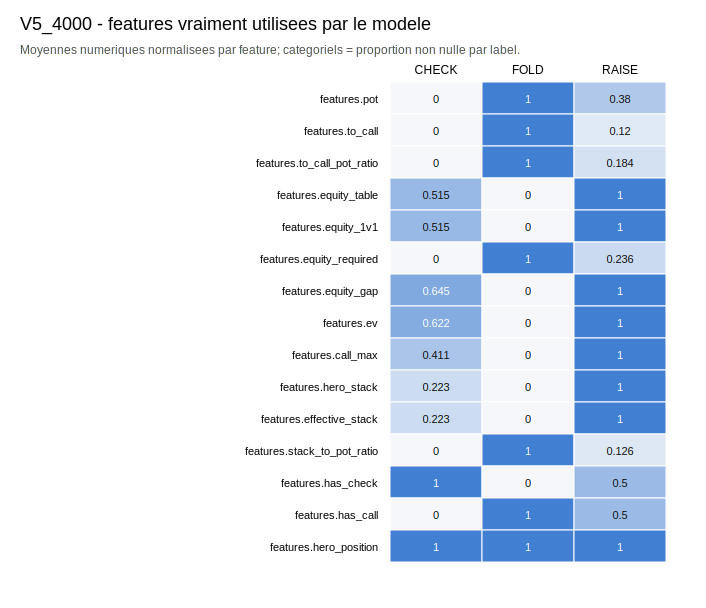

### V5_4000 - features exclues car constantes

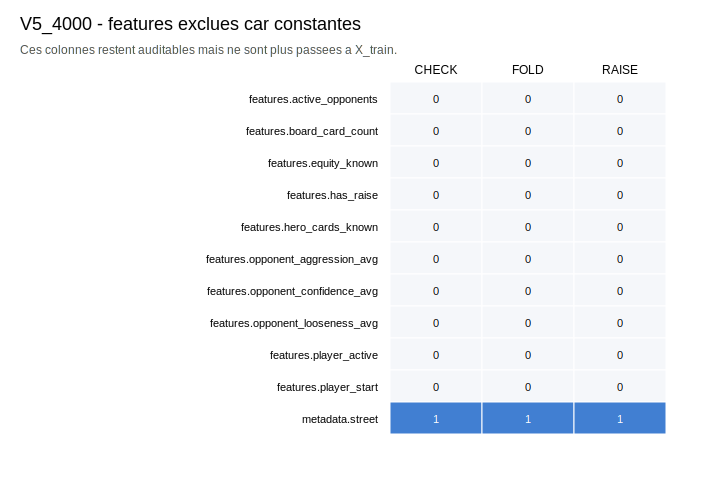

### Heatmap audit-only non affichee par defaut`c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5_4000\heatmap_audit_only_features.svg`

### Feature status summary

# Feature Status Summary

| feature name | status | reason | nunique | zero_ratio | mean CHECK | mean FOLD | mean RAISE |
|---|---|---|---:|---:|---:|---:|---:|
| `features.pot` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 15 | 0 | 279.131737 | 333.353293 | 299.760479 |
| `features.to_call` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 12 | 0.5 | 0 | 166.619162 | 20 |
| `features.to_call_pot_ratio` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 16 | 0.5 | 0 | 0.375376 | 0.069175 |
| `features.equity_table` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 2 | 0.49501 | 0.51497 | 0 | 1 |
| `features.equity_1v1` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 2 | 0.49501 | 0.51497 | 0 | 1 |
| `features.equity_required` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 16 | 0.5 | 0 | 0.256593 | 0.060522 |
| `features.equity_gap` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 17 | 0.161677 | 0.51497 | -0.256593 | 0.939478 |
| `features.ev` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 20 | 0.161677 | 123.323353 | -166.619162 | 299.760479 |
| `features.call_max` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 10 | 0.49501 | 123323229.966514 | 0 | 299760179.272817 |
| `features.hero_stack` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 13 | 0 | 1078.562874 | 957.784431 | 1498.802395 |
| `features.effective_stack` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 13 | 0 | 1078.562874 | 957.784431 | 1498.802395 |
| `features.stack_to_pot_ratio` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 41 | 0 | 5.145779 | 5.492772 | 5.189365 |
| `features.has_check` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 2 | 0.5 | 1 | 0 | 0.5 |
| `features.has_call` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 2 | 0.5 | 0 | 1 | 0.5 |
| `features.hero_position` | used_by_model | `Present in feature_contract.features_model_used and passed to sklearn.` | 2 | 0 | NA | NA | NA |
| `features.active_opponents` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 1 | 1 | 1 |
| `features.board_card_count` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 5 | 5 | 5 |
| `features.equity_known` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 1 | 1 | 1 |
| `features.has_raise` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 1 | 1 | 1 |
| `features.hero_cards_known` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 1 | 1 | 1 |
| `features.opponent_aggression_avg` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 0.5 | 0.5 | 0.5 |
| `features.opponent_confidence_avg` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 1 | 0 | 0 | 0 |
| `features.opponent_looseness_avg` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 0.5 | 0.5 | 0.5 |
| `features.player_active` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 2 | 2 | 2 |
| `features.player_start` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | 2 | 2 | 2 |
| `metadata.street` | constant_excluded | `Constant or quasi-constant in this v5_4000 CSV; excluded from X_train.` | 1 | 0 | NA | NA | NA |
| `confidence.board_cards_min` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `confidence.buttons_min` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `confidence.hero_cards_min` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `confidence.hero_position` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `confidence.player_count` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `confidence.pot_ocr` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `confidence.to_call_ocr` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `features.board_cards` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 248 | 0 | NA | NA | NA |
| `features.buttons` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 17 | 0 | NA | NA | NA |
| `features.buttons_active` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 2 | 0 | NA | NA | NA |
| `features.hero_cards` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 236 | 0 | NA | NA | NA |
| `features.opponent_profiles` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `features.players` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 13 | 0 | NA | NA | NA |
| `metadata.decision_engine_fix_date` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `metadata.decision_engine_fix_id` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `metadata.decision_engine_version` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `metadata.decision_mode` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `metadata.game` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `metadata.git_commit` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `metadata.hand_id` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1002 | 0 | 809.476048 | 493.523952 | 1345.5 |
| `metadata.legacy_rules_version` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `metadata.new_party_state` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 1 | NA | NA | NA |
| `metadata.scan_count` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | 1 | 1 | 1 |
| `metadata.status` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `quality_flags.board_uncertain` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 1 | NA | NA | NA |
| `quality_flags.buttons_incoherent` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 1 | NA | NA | NA |
| `quality_flags.hero_cards_uncertain` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 1 | NA | NA | NA |
| `quality_flags.hero_position_low_confidence` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 1 | NA | NA | NA |
| `quality_flags.opponent_count_uncertain` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `quality_flags.pot_to_call_incoherent` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 1 | NA | NA | NA |
| `quality_flags.street_transient` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 1 | NA | NA | NA |
| `quality_flags.usable_for_training` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `recorded_at` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `schema_version` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `snapshot_id` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1002 | 0 | NA | NA | NA |
| `type` | audit_only | `Kept in the CSV for audit and traceability only; not passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `audit.action_frequencies` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 39 | 0 | NA | NA | NA |
| `audit.candidate_confidence` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 2 | 0 | NA | NA | NA |
| `audit.dominant_action` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 7 | 0 | NA | NA | NA |
| `audit.dominant_action_frequency` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 33 | 0 | 0.998962 | 0.984494 | 1 |
| `audit.exploitability_last` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 33 | 0 | 0.303768 | 0.179237 | NA |
| `audit.iterations` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 3 | 0 | 62.5 | 62.5 | NA |
| `audit.label_quality` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 2 | 0 | NA | NA | NA |
| `audit.label_source` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 2 | 0 | NA | NA | NA |
| `audit.normalized_action` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 3 | 0 | NA | NA | NA |
| `audit.raw_action` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 7 | 0 | NA | NA | NA |
| `audit.source_id` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1002 | 0 | NA | NA | NA |
| `audit.weak_rule_reason` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 4 | 0 | NA | NA | NA |
| `debug.board_scan_raw` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.board_state_raw` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.button_texts_raw` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.decision_reason` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 4 | 0 | NA | NA | NA |
| `debug.hero_scan_raw` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.hero_state_raw` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.scan_status` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.target_button.bbox` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.target_button.index` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.target_button.label` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.target_button.state` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.target_button.text` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `debug.target_button.value` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `labels.fallback_reason` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `labels.final_action` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 3 | 0 | NA | NA | NA |
| `labels.known_bug_risk` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 1 | NA | NA | NA |
| `labels.label_exclusion_reason` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `labels.label_valid` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `labels.legacy_action` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 3 | 0 | NA | NA | NA |
| `labels.legacy_raise_amount` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `labels.legacy_reason` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 4 | 0 | NA | NA | NA |
| `labels.ml_action` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `labels.ml_confidence` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 1 | 0 | NA | NA | NA |
| `metadata.label_source` | leakage_excluded | `Audit/debug/label/solver-derived target field; never passed to sklearn.` | 2 | 0 | NA | NA | NA |

Leakage used by model: `[]`.
CALL was not added. Bot live connection was not modified.


### Logistic regression coefficients

# Logistic Regression Coefficients

Transient logistic_regression fit for interpretability only. The saved production/offline model artifact was not changed.

## Class CHECK

| positive feature | coefficient | negative feature | coefficient |
|---|---:|---|---:|
| `features.ev` | 0.223949 | `features.to_call` | -0.264737 |
| `features.pot` | 0.184401 | `features.has_call` | -0.002559 |
| `features.call_max` | 0.178704 | `features.hero_position=IP` | -0.001763 |
| `features.has_check` | 0.003303 | `features.to_call_pot_ratio` | -0.000693 |
| `features.hero_position=OOP` | 0.002507 | `features.equity_required` | -0.000509 |
| `features.stack_to_pot_ratio` | 0.001051 | `features.effective_stack` | -0.000405 |
| `features.equity_gap` | 0.000748 | `features.hero_stack` | -0.000405 |
| `features.equity_1v1` | 0.000240 | `features.equity_1v1` | 0.000240 |
| `features.equity_table` | 0.000240 | `features.equity_table` | 0.000240 |
| `features.effective_stack` | -0.000405 | `features.equity_gap` | 0.000748 |
| `features.hero_stack` | -0.000405 | `features.stack_to_pot_ratio` | 0.001051 |
| `features.equity_required` | -0.000509 | `features.hero_position=OOP` | 0.002507 |

## Class FOLD

| positive feature | coefficient | negative feature | coefficient |
|---|---:|---|---:|
| `features.to_call` | 0.318656 | `features.call_max` | -0.357407 |
| `features.pot` | 0.067412 | `features.ev` | -0.318656 |
| `features.has_call` | 0.001926 | `features.has_check` | -0.001833 |
| `features.effective_stack` | 0.001218 | `features.hero_position=OOP` | -0.000839 |
| `features.hero_stack` | 0.001218 | `features.equity_gap` | -0.000495 |
| `features.hero_position=IP` | 0.000932 | `features.equity_1v1` | -0.000000 |
| `features.to_call_pot_ratio` | 0.000723 | `features.equity_table` | -0.000000 |
| `features.equity_required` | 0.000495 | `features.stack_to_pot_ratio` | 0.000460 |
| `features.stack_to_pot_ratio` | 0.000460 | `features.equity_required` | 0.000495 |
| `features.equity_1v1` | -0.000000 | `features.to_call_pot_ratio` | 0.000723 |
| `features.equity_table` | -0.000000 | `features.hero_position=IP` | 0.000932 |
| `features.equity_gap` | -0.000495 | `features.effective_stack` | 0.001218 |

## Class RAISE

| positive feature | coefficient | negative feature | coefficient |
|---|---:|---|---:|
| `features.call_max` | 0.178704 | `features.pot` | -0.251813 |
| `features.ev` | 0.094707 | `features.to_call` | -0.053919 |
| `features.hero_position=IP` | 0.000831 | `features.hero_position=OOP` | -0.001668 |
| `features.has_call` | 0.000633 | `features.stack_to_pot_ratio` | -0.001511 |
| `features.equity_required` | 0.000014 | `features.has_check` | -0.001470 |
| `features.to_call_pot_ratio` | -0.000030 | `features.effective_stack` | -0.000813 |
| `features.equity_1v1` | -0.000240 | `features.hero_stack` | -0.000813 |
| `features.equity_table` | -0.000240 | `features.equity_gap` | -0.000253 |
| `features.equity_gap` | -0.000253 | `features.equity_1v1` | -0.000240 |
| `features.effective_stack` | -0.000813 | `features.equity_table` | -0.000240 |
| `features.hero_stack` | -0.000813 | `features.to_call_pot_ratio` | -0.000030 |
| `features.has_check` | -0.001470 | `features.equity_required` | 0.000014 |


### Ablation summary

# Ablation Summary

| variant | status | rows | features | selected model | macro_f1 | accuracy |
|---|---|---:|---:|---|---:|---:|
| `full_current` | `ok` | 1002 | 26 | `random_forest` | 0.992016 | 0.992032 |
| `without_constant_features` | `ok` | 1002 | 15 | `random_forest` | 0.992016 | 0.992032 |
| `without_equity_gap_ev_call_max` | `ok` | 1002 | 12 | `random_forest` | 0.988017 | 0.988048 |
| `without_equity_table_equity_1v1` | `ok` | 1002 | 13 | `random_forest` | 0.988017 | 0.988048 |
| `minimal_pot_call_stack_actions_position` | `ok` | 1002 | 9 | `random_forest` | 0.988017 | 0.988048 |
| `solver_candidate_only` | `ok` | 490 | 15 | `logistic_regression` | 1 | 1 |
| `weak_rule_bootstrap_only` | `ok` | 512 | 15 | `random_forest` | 0.982703 | 0.976562 |

Reading guide: compare each macro_f1 to `without_constant_features`; drops indicate feature groups carrying signal.
This summary is reporting-only and does not change the saved model.


In [77]:
from IPython.display import SVG, display, Markdown

heatmap_model_dir = V5_4000_MODEL_DIR if (V5_4000_MODEL_DIR / "heatmap_model_used_features.svg").exists() else V5_MODEL_DIR
for title, path in [
    ("V5_4000 - features utilisees par le modele", heatmap_model_dir / "heatmap_model_used_features.svg"),
    ("V5_4000 - features exclues car constantes", heatmap_model_dir / "heatmap_excluded_constant_features.svg"),
]:
    display(Markdown(f"### {title}"))
    if path.exists():
        display(SVG(filename=str(path)))
    else:
        print("Fichier absent:", path)

audit_only_path = heatmap_model_dir / "heatmap_audit_only_features.svg"
display(Markdown(f"### Heatmap audit-only non affichee par defaut`{audit_only_path}`"))

for title, path in [
    ("Feature status summary", heatmap_model_dir / "feature_status_summary.md"),
    ("Logistic regression coefficients", heatmap_model_dir / "model_coefficients.md"),
    ("Ablation summary", heatmap_model_dir / "ablation_summary.md"),
]:
    display(Markdown(f"### {title}"))
    if path.exists():
        display(Markdown(path.read_text(encoding="utf-8")))
    else:
        print("Fichier absent:", path)


### Correlation des inputs modele

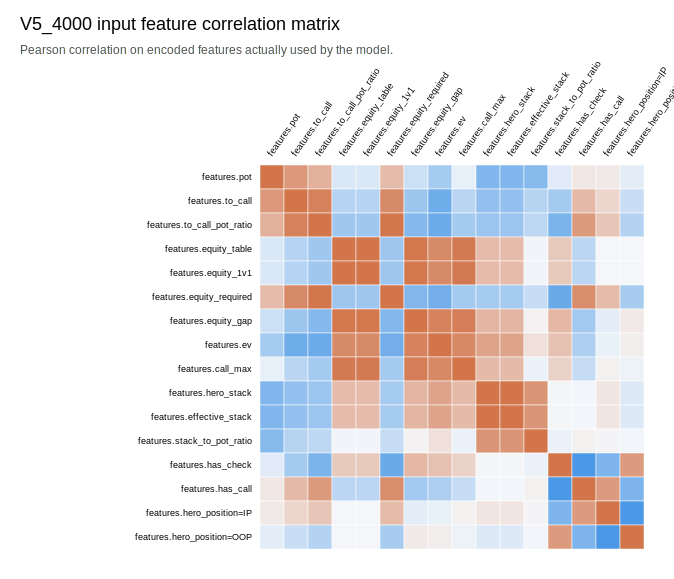

### Learning curve

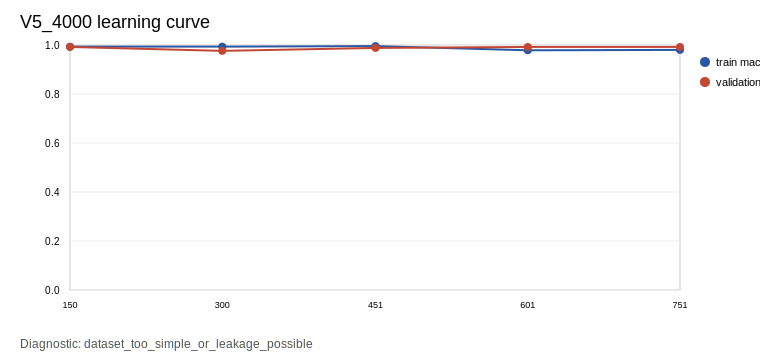

### High correlation pairs

# High Correlation Pairs

Only encoded features actually used by the model are included.

## Absolute Correlation > 0.90

| feature A | feature B | correlation | comment |
|---|---|---:|---|
| `features.equity_table` | `features.equity_1v1` | 1.000000 | `suspect_redundant` |
| `features.has_check` | `features.has_call` | -1.000000 | `suspect_redundant` |
| `features.hero_position=IP` | `features.hero_position=OOP` | -1.000000 | `suspect_redundant` |
| `features.hero_stack` | `features.effective_stack` | 1.000000 | `suspect_redundant` |
| `features.to_call_pot_ratio` | `features.equity_required` | 0.986217 | `suspect_redundant` |
| `features.equity_1v1` | `features.equity_gap` | 0.980700 | `suspect_redundant` |
| `features.equity_table` | `features.equity_gap` | 0.980700 | `suspect_redundant` |
| `features.equity_1v1` | `features.call_max` | 0.957141 | `suspect_redundant` |
| `features.equity_table` | `features.call_max` | 0.957141 | `suspect_redundant` |
| `features.equity_gap` | `features.call_max` | 0.935990 | `redondant` |
| `features.to_call` | `features.to_call_pot_ratio` | 0.902033 | `redondant` |

## Absolute Correlation > 0.80

| feature A | feature B | correlation | comment |
|---|---|---:|---|
| `features.equity_table` | `features.equity_1v1` | 1.000000 | `suspect_redundant` |
| `features.has_check` | `features.has_call` | -1.000000 | `suspect_redundant` |
| `features.hero_position=IP` | `features.hero_position=OOP` | -1.000000 | `suspect_redundant` |
| `features.hero_stack` | `features.effective_stack` | 1.000000 | `suspect_redundant` |
| `features.to_call_pot_ratio` | `features.equity_required` | 0.986217 | `suspect_redundant` |
| `features.equity_1v1` | `features.equity_gap` | 0.980700 | `suspect_redundant` |
| `features.equity_table` | `features.equity_gap` | 0.980700 | `suspect_redundant` |
| `features.equity_1v1` | `features.call_max` | 0.957141 | `suspect_redundant` |
| `features.equity_table` | `features.call_max` | 0.957141 | `suspect_redundant` |
| `features.equity_gap` | `features.call_max` | 0.935990 | `redondant` |
| `features.to_call` | `features.to_call_pot_ratio` | 0.902033 | `redondant` |
| `features.equity_gap` | `features.ev` | 0.894816 | `acceptable_monitor` |
| `features.ev` | `features.call_max` | 0.850742 | `acceptable_monitor` |
| `features.equity_1v1` | `features.ev` | 0.834339 | `acceptable_monitor` |
| `features.equity_table` | `features.ev` | 0.834339 | `acceptable_monitor` |
| `features.to_call` | `features.equity_required` | 0.831027 | `suspect_redundant` |
| `features.equity_required` | `features.has_call` | 0.806898 | `acceptable_monitor` |
| `features.equity_required` | `features.has_check` | -0.806898 | `acceptable_monitor` |
| `features.to_call_pot_ratio` | `features.ev` | -0.803274 | `acceptable_monitor` |

## Watched Pairs

| feature A | feature B | correlation | comment |
|---|---|---:|---|
| `features.call_max` | `features.equity_gap` | 0.935990 | `redondant` |
| `features.call_max` | `features.ev` | 0.850742 | `acceptable_monitor` |
| `features.effective_stack` | `features.hero_stack` | 1.000000 | `suspect_redundant` |
| `features.equity_1v1` | `features.equity_table` | 1.000000 | `suspect_redundant` |
| `features.equity_gap` | `features.ev` | 0.894816 | `acceptable_monitor` |
| `features.equity_required` | `features.to_call` | 0.831027 | `suspect_redundant` |
| `features.pot` | `features.stack_to_pot_ratio` | -0.652342 | `acceptable_monitor` |
| `features.pot` | `features.to_call` | 0.729017 | `acceptable_monitor` |


### Multicollinearity report

# Multicollinearity Report

## Strong Correlations

| feature A | feature B | correlation | comment |
|---|---|---:|---|
| `features.equity_table` | `features.equity_1v1` | 1.000000 | `suspect_redundant` |
| `features.has_check` | `features.has_call` | -1.000000 | `suspect_redundant` |
| `features.hero_position=IP` | `features.hero_position=OOP` | -1.000000 | `suspect_redundant` |
| `features.hero_stack` | `features.effective_stack` | 1.000000 | `suspect_redundant` |
| `features.to_call_pot_ratio` | `features.equity_required` | 0.986217 | `suspect_redundant` |
| `features.equity_1v1` | `features.equity_gap` | 0.980700 | `suspect_redundant` |
| `features.equity_table` | `features.equity_gap` | 0.980700 | `suspect_redundant` |
| `features.equity_1v1` | `features.call_max` | 0.957141 | `suspect_redundant` |
| `features.equity_table` | `features.call_max` | 0.957141 | `suspect_redundant` |
| `features.equity_gap` | `features.call_max` | 0.935990 | `redondant` |
| `features.to_call` | `features.to_call_pot_ratio` | 0.902033 | `redondant` |
| `features.equity_gap` | `features.ev` | 0.894816 | `acceptable_monitor` |
| `features.ev` | `features.call_max` | 0.850742 | `acceptable_monitor` |
| `features.equity_1v1` | `features.ev` | 0.834339 | `acceptable_monitor` |
| `features.equity_table` | `features.ev` | 0.834339 | `acceptable_monitor` |
| `features.to_call` | `features.equity_required` | 0.831027 | `suspect_redundant` |
| `features.equity_required` | `features.has_call` | 0.806898 | `acceptable_monitor` |
| `features.equity_required` | `features.has_check` | -0.806898 | `acceptable_monitor` |
| `features.to_call_pot_ratio` | `features.ev` | -0.803274 | `acceptable_monitor` |

## Variance Inflation Factor

| feature | VIF | recommendation |
|---|---:|---|
| `features.pot` | 6.783406 | `garder` |
| `features.to_call` | 447.009859 | `supprimer` |
| `features.to_call_pot_ratio` | 736.888683 | `supprimer` |
| `features.equity_table` | inf | `supprimer` |
| `features.equity_1v1` | inf | `supprimer` |
| `features.equity_required` | 56062.039117 | `supprimer` |
| `features.equity_gap` | 1079286.315036 | `supprimer` |
| `features.ev` | 1247.313267 | `supprimer` |
| `features.call_max` | 463.160026 | `supprimer` |
| `features.hero_stack` | inf | `supprimer` |
| `features.effective_stack` | inf | `supprimer` |
| `features.stack_to_pot_ratio` | 7.292647 | `garder` |
| `features.has_check` | inf | `supprimer` |
| `features.has_call` | inf | `supprimer` |
| `features.hero_position=IP` | inf | `fusionner` |
| `features.hero_position=OOP` | inf | `fusionner` |

## Redundant Candidate Features

- `features.call_max`
- `features.effective_stack`
- `features.equity_1v1`
- `features.equity_gap`
- `features.equity_required`
- `features.has_call`
- `features.hero_position=OOP`
- `features.to_call_pot_ratio`


### Robust generalization report

# Robust Generalization Report

| variant | status | rows | features | selected model | accuracy | macro F1 | comment |
|---|---|---:|---:|---|---:|---:|---|
| `random_split` | `ok` | 1002 | 15 | `random_forest` | 0.992032 | 0.992016 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `solver_candidate_only` | `ok` | 490 | 15 | `logistic_regression` | 1 | 1 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `weak_rule_bootstrap_only` | `ok` | 512 | 15 | `random_forest` | 0.976562 | 0.982703 | `acceptable` |
| `equity_derived_features_only` | `ok` | 1002 | 6 | `random_forest` | 0.972112 | 0.97202 | `acceptable` |
| `no_equity_derived_features` | `ok` | 1002 | 9 | `random_forest` | 0.988048 | 0.988017 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `pot_stack_actions_position_only` | `ok` | 1002 | 9 | `random_forest` | 0.988048 | 0.988017 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `train_solver_candidate_validate_weak_rule_bootstrap` | `ok` | 1002 | 15 | `logistic_regression` | 0.347656 | 0.502458 | `weak_generalization` |
| `train_weak_rule_bootstrap_validate_solver_candidate` | `ok` | 1002 | 15 | `logistic_regression` | 0.669388 | 0.267319 | `weak_generalization` |


### Current vs BB normalized

# Current vs BB-Normalized Comparison

Recommendation: `bb_model_is_viable_experimental_candidate`

| model | accuracy | macro F1 | features | learning diagnostic | high corr pairs > .90 |
|---|---:|---:|---:|---|---:|
| current_v5_4000 | 0.992032 | 0.992016 | 15 | `dataset_too_simple_or_leakage_possible` | 11 |
| bb_normalized_experimental | 0.992032 | 0.992016 | 16 | `dataset_too_simple_or_leakage_possible` | 12 |

## Delta

- accuracy: `0.0`
- macro_f1: `0.0`
- feature_count: `1`

## Robustness Snapshot

| model | variant | status | macro F1 | comment |
|---|---|---|---:|---|
| `current_v5_4000` | `random_split` | `ok` | 0.992016 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `current_v5_4000` | `solver_candidate_only` | `ok` | 1 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `current_v5_4000` | `weak_rule_bootstrap_only` | `ok` | 0.982703 | `acceptable` |
| `current_v5_4000` | `equity_derived_features_only` | `ok` | 0.97202 | `acceptable` |
| `current_v5_4000` | `no_equity_derived_features` | `ok` | 0.988017 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `current_v5_4000` | `pot_stack_actions_position_only` | `ok` | 0.988017 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `current_v5_4000` | `train_solver_candidate_validate_weak_rule_bootstrap` | `ok` | 0.502458 | `weak_generalization` |
| `current_v5_4000` | `train_weak_rule_bootstrap_validate_solver_candidate` | `ok` | 0.267319 | `weak_generalization` |
| `bb_normalized_experimental` | `random_split` | `ok` | 0.992016 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `bb_normalized_experimental` | `solver_candidate_only` | `ok` | 1 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `bb_normalized_experimental` | `weak_rule_bootstrap_only` | `ok` | 0.982703 | `acceptable` |
| `bb_normalized_experimental` | `equity_derived_features_only` | `ok` | 0.97202 | `acceptable` |
| `bb_normalized_experimental` | `no_equity_derived_features` | `ok` | 0.988017 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `bb_normalized_experimental` | `pot_stack_actions_position_only` | `ok` | 0.988017 | `very_high_score_check_for_synthetic_simplicity_or_leakage` |
| `bb_normalized_experimental` | `train_solver_candidate_validate_weak_rule_bootstrap` | `ok` | 0.502458 | `weak_generalization` |
| `bb_normalized_experimental` | `train_weak_rule_bootstrap_validate_solver_candidate` | `ok` | 0.267319 | `weak_generalization` |

## Coefficient Snapshot

### current_v5_4000

| class | top positive coefficient | top negative coefficient |
|---|---|---|
| `CHECK` | `features.ev` `0.223949` | `features.to_call` `-0.264737` |
| `FOLD` | `features.to_call` `0.318656` | `features.call_max` `-0.357407` |
| `RAISE` | `features.call_max` `0.178704` | `features.pot` `-0.251813` |

### bb_normalized_experimental

| class | top positive coefficient | top negative coefficient |
|---|---|---|
| `CHECK` | `features.ev_bb` `0.003784` | `features.to_call_bb` `-0.004336` |
| `FOLD` | `features.to_call_bb` `0.00546` | `features.call_max_bb` `-0.007314` |
| `RAISE` | `features.call_max_bb` `0.003657` | `features.pot_bb` `-0.004322` |


The BB model is experimental and saved in a separate folder. The current model artifact was not overwritten.


In [78]:
from IPython.display import SVG, display, Markdown

advanced_dir = V5_4000_MODEL_DIR
for title, path in [
    ("Correlation des inputs modele", advanced_dir / "input_feature_correlation_matrix.svg"),
    ("Learning curve", advanced_dir / "learning_curve.svg"),
]:
    display(Markdown(f"### {title}"))
    if path.exists():
        display(SVG(filename=str(path)))
    else:
        print("Fichier absent:", path)

for title, path in [
    ("High correlation pairs", advanced_dir / "high_correlation_pairs.md"),
    ("Multicollinearity report", advanced_dir / "multicollinearity_report.md"),
    ("Robust generalization report", advanced_dir / "robust_generalization_report.md"),
    ("Current vs BB normalized", V5_4000_MODEL_DIR.parent / "bootstrap_model_v5_4000_bb" / "comparison_current_vs_bb.md"),
]:
    display(Markdown(f"### {title}"))
    if path.exists():
        display(Markdown(path.read_text(encoding="utf-8")))
    else:
        print("Fichier absent:", path)


In [79]:
active_candidates = V5_4000_CANDIDATES if V5_4000_CANDIDATES.exists() else V5_CANDIDATES
rows = load_csv(active_candidates)
kept = [row for row in rows if not is_true(row.get("excluded"))]
rejected = [row for row in rows if is_true(row.get("excluded"))]

def nested_count(rows, a, b):
    table = defaultdict(Counter)
    for row in rows:
        table[row.get(a) or "UNKNOWN"][row.get(b) or "UNKNOWN"] += 1
    return {key: dict(counts) for key, counts in sorted(table.items())}

print("Dataset:", active_candidates)
print("Total:", len(rows), "Kept:", len(kept), "Rejected:", len(rejected))
print("Labels:", dict(Counter(row.get("bootstrap_label") or row.get("labels.final_action") for row in kept)))
print("Sources:", dict(Counter(row.get("label_source") or row.get("metadata.label_source") for row in kept)))
print("Rejets:", dict(Counter(row.get("exclusion_reason") for row in rejected)))
print("Classes par source:", json.dumps(nested_count(kept, "metadata.label_source", "labels.final_action"), ensure_ascii=False, indent=2))
print("Classes par position:", json.dumps(nested_count(kept, "features.hero_position", "labels.final_action"), ensure_ascii=False, indent=2))


Dataset: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_candidate_dataset_v5_4000\candidates.csv
Total: 1512 Kept: 1002 Rejected: 510
Labels: {'FOLD': 334, 'CHECK': 334, 'RAISE': 334}
Sources: {'solver_candidate': 490, 'weak_rule_bootstrap': 512}
Rejets: {'all_in_excluded': 510}
Classes par source: {
  "solver_candidate": {
    "FOLD": 328,
    "CHECK": 162
  },
  "weak_rule_bootstrap": {
    "CHECK": 172,
    "FOLD": 6,
    "RAISE": 334
  }
}
Classes par position: {
  "IP": {
    "FOLD": 163,
    "RAISE": 167
  },
  "OOP": {
    "CHECK": 334,
    "FOLD": 171,
    "RAISE": 167
  }
}


In [80]:
contract_path = V5_4000_MODEL_DIR / "feature_contract.json"
if not contract_path.exists():
    contract_path = V5_MODEL_DIR / "feature_contract.json"

if contract_path.exists():
    contract = load_json(contract_path)
    print("Contrat:", contract_path)
    print("Schema:", contract.get("schema"))
    print("Features modele:", len(contract.get("feature_order", [])))
    for feature in contract.get("feature_order", []):
        print("-", feature)
    print("Colonnes ignorees:", len(contract.get("ignored_columns", [])))
    print("Leakage exclu:", contract.get("leakage_columns_excluded"))
else:
    print("Contrat absent:", contract_path)


Contrat: c:\Users\Éleve\Pictures\Traine_aide_decission\outputs\readiness\bootstrap_model_v5_4000\feature_contract.json
Schema: bootstrap_v5_dist_aligned_flat_csv
Features modele: 15
- features.pot
- features.to_call
- features.to_call_pot_ratio
- features.equity_table
- features.equity_1v1
- features.equity_required
- features.equity_gap
- features.ev
- features.call_max
- features.hero_stack
- features.effective_stack
- features.stack_to_pot_ratio
- features.has_check
- features.has_call
- features.hero_position
Colonnes ignorees: 79
Leakage exclu: ['audit.action_frequencies', 'audit.candidate_confidence', 'audit.dominant_action', 'audit.dominant_action_frequency', 'audit.exploitability_last', 'audit.iterations', 'audit.label_quality', 'audit.label_source', 'audit.normalized_action', 'audit.raw_action', 'audit.source_id', 'audit.weak_rule_reason', 'debug.board_scan_raw', 'debug.board_state_raw', 'debug.button_texts_raw', 'debug.decision_reason', 'debug.hero_scan_raw', 'debug.hero_stat

## Lecture recommandee

Avant d'ajouter `CALL`, verifier manuellement quelques lignes du dataset actif. Si les spots semblent artificiels ou trop homogenes, il faut diversifier les scenarios avant de faire grossir le dataset.
